In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



#load data set
model = pd.read_csv("dataset_final.csv")

In [2]:
#EDA expolaroty data analysis
model.info()
model.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   usia                            2000 non-null   int64  
 1   jenis_kelamin                   2000 non-null   object 
 2   bmi                             2000 non-null   float64
 3   status_merokok                  2000 non-null   object 
 4   tingkat_aktivitas_fisik         2000 non-null   object 
 5   jam_tidur_per_malam             2000 non-null   int64  
 6   tingkat_stres                   2000 non-null   object 
 7   frekuensi_makan_pedas           2000 non-null   object 
 8   frekuensi_makan_berlemak        2000 non-null   object 
 9   konsumsi_kopi_per_hari          2000 non-null   int64  
 10  konsumsi_alkohol                2000 non-null   object 
 11  minuman_bersoda_per_minggu      2000 non-null   int64  
 12  frekuensi_fast_food_per_minggu  20

,usia,bmi,jam_tidur_per_malam,konsumsi_kopi_per_hari,minuman_bersoda_per_minggu,frekuensi_fast_food_per_minggu,risiko_gerd
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.0000
mean,41.675000,26.570050,6.590000,2.474500,7.091000,3.589500,0.5050
std,13.666666,4.889564,1.691251,1.701704,4.357317,2.277407,0.5001
min,18.000000,18.000000,4.000000,0.000000,0.000000,0.000000,0.0000
25%,30.000000,22.300000,5.000000,1.000000,3.000000,2.000000,0.0000
50%,42.000000,26.700000,7.000000,2.000000,7.000000,4.000000,1.0000
75%,53.000000,30.900000,8.000000,4.000000,11.000000,6.000000,1.0000
max,65.000000,35.000000,9.000000,5.000000,14.000000,7.000000,1.0000


In [3]:
model.isnull().sum()

usia                              0
jenis_kelamin                     0
bmi                               0
status_merokok                    0
tingkat_aktivitas_fisik           0
jam_tidur_per_malam               0
tingkat_stres                     0
frekuensi_makan_pedas             0
frekuensi_makan_berlemak          0
konsumsi_kopi_per_hari            0
konsumsi_alkohol                  0
minuman_bersoda_per_minggu        0
frekuensi_fast_food_per_minggu    0
makan_larut_malam                 0
risiko_gerd                       0
dtype: int64

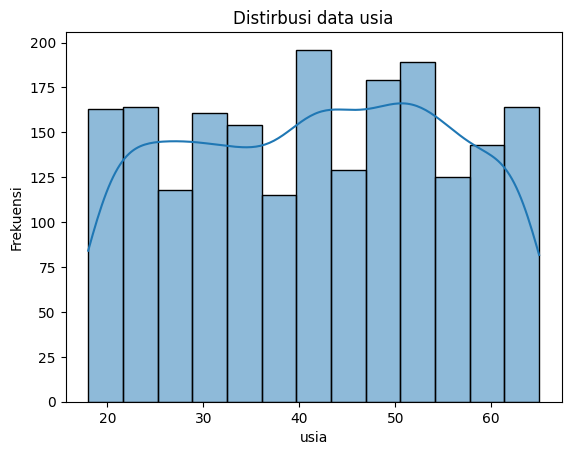

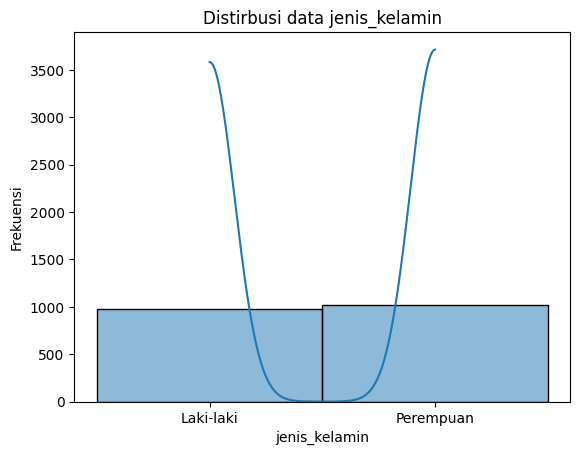

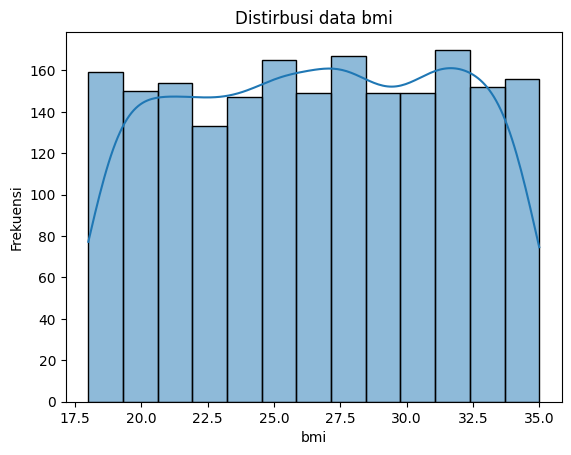

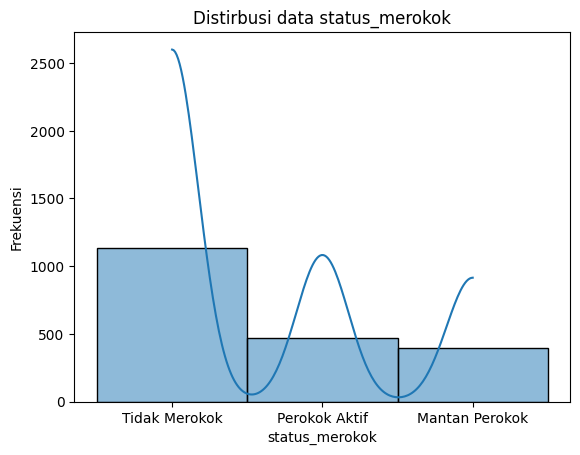

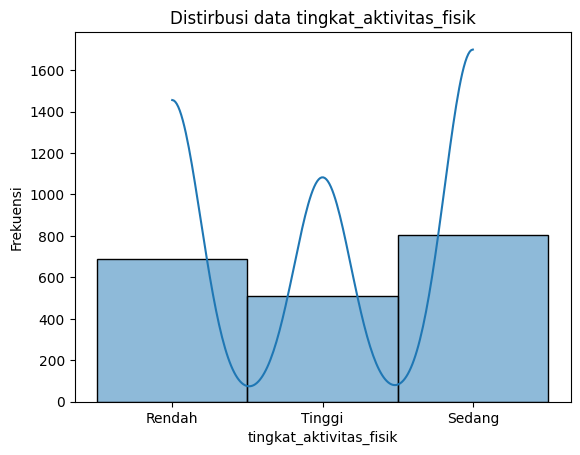

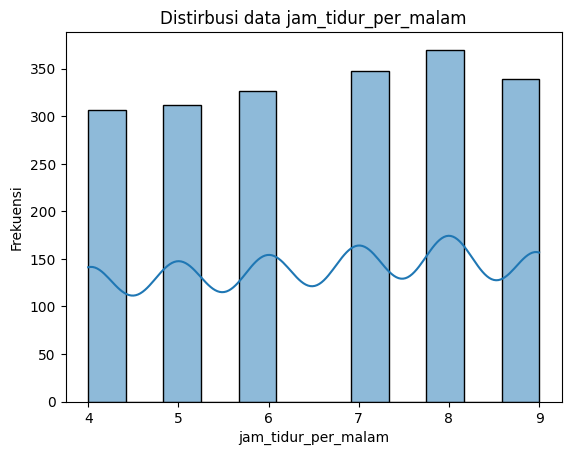

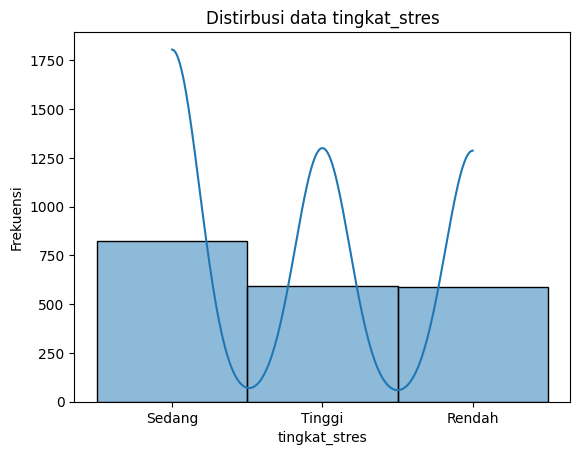

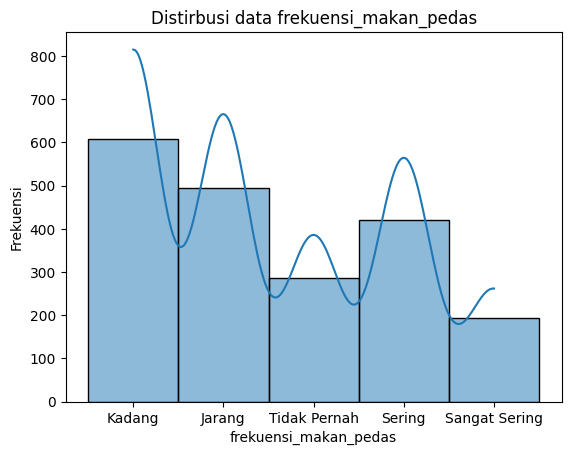

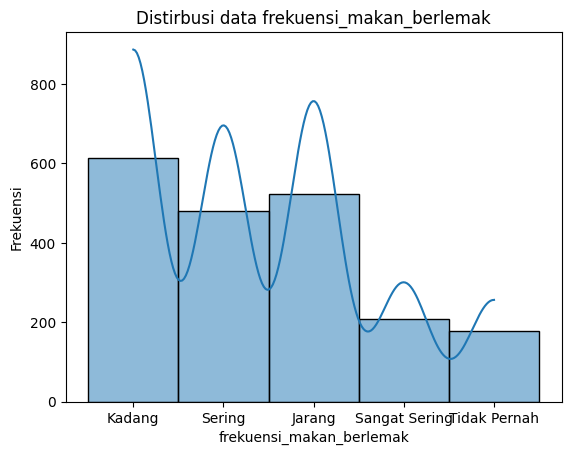

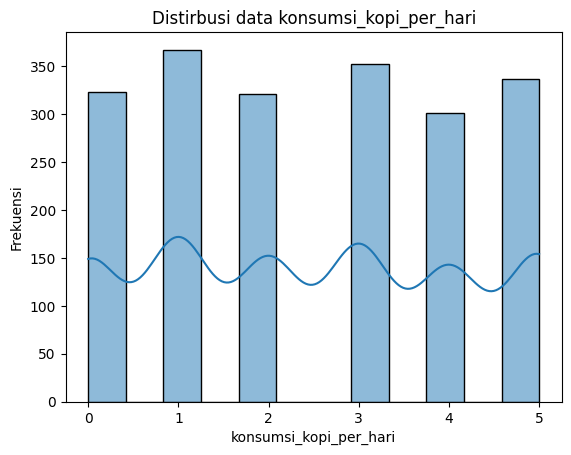

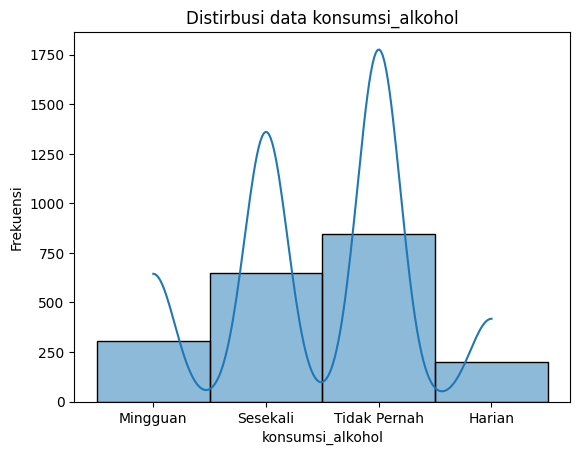

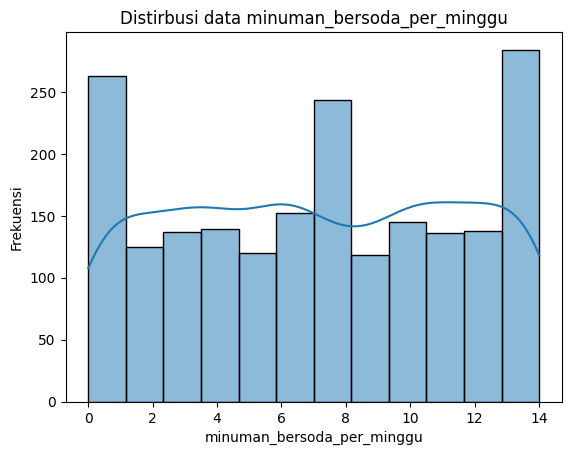

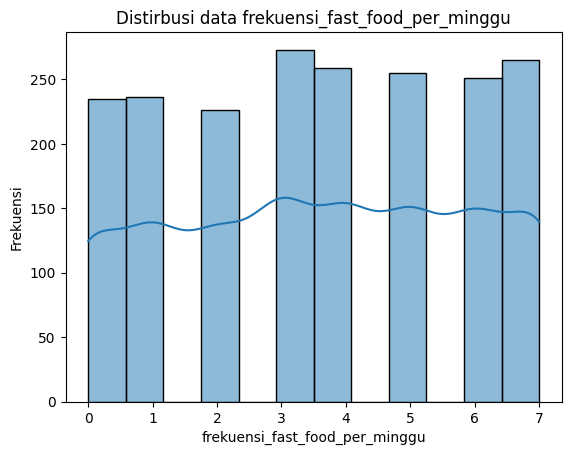

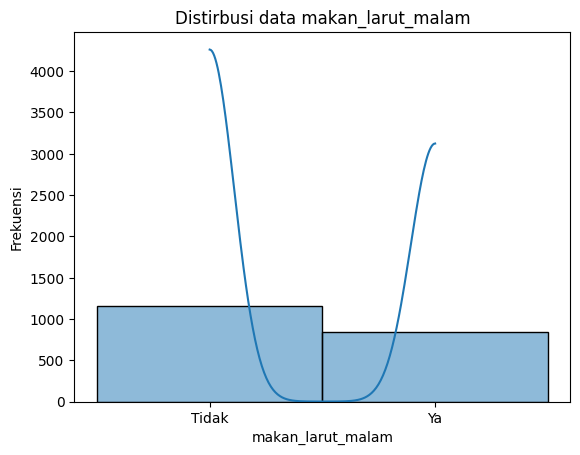

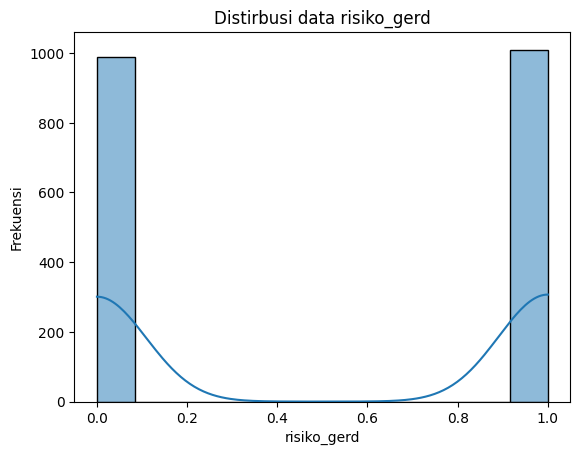

In [23]:
#melihat distibusi data mengunakan hhsitogram

for i in model.columns:
    
    plt.Figure(figsize=(10,5))
    sns.histplot(model[i], kde=True)
    
    plt.title(f"Distirbusi data {i}")
    plt.xlabel(i)
    plt.ylabel("Frekuensi")
    plt.show() 

TypeError: ufunc 'divide' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

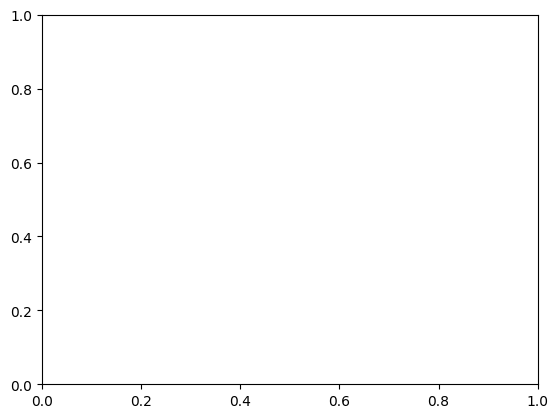

In [ ]:
#detector and handling outliers
def outlier(model):
    Q1 = int(model["risiko_gerd"].quantile(0.25))
    Q3 = int(model["risiko_gerd"].quantile(0.75))
         
    IQR = Q3 - Q1
    lower_data = Q1 - 1.5 * IQR
    upper_data = Q3 + 1.5 * IQR
        
    outliers = model[(model["risiko_gerd"] < lower_data) | (model["risiko_gerd"] > upper_data)]
        
    return outliers
plt.boxplot(model["risiko_gerd"])
plt.title("outliaes di setiap fitur")
plt.show()

In [ ]:
#spliting data

x = model.drop(columns=['risiko_gerd']) #DISINI KITA MEMISAHKAN ANTARA FITUR DAN TARGET
y = model['risiko_gerd'] #INI BAGIAN TARGETNYA

x_latih, x_uji, y_latih, y_uji = train_test_split(x, y , test_size=0.3, random_state=42)

In [ ]:
#feature encoding
def encoding():
    encode_model = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

    x_latih_encode = encode_model.fit_transform(x_latih[['usia', 'bmi', 'jam_tidur_per_malam', 'konsumsi_kopi_per_hari', 'minuman_bersoda_per_minggu', 'frekuensi_fast_food_per_minggu']])
    x_uji_encode = encode_model.transform(x_uji[['usia', 'bmi', 'jam_tidur_per_malam', 'konsumsi_kopi_per_hari', 'minuman_bersoda_per_minggu', 'frekuensi_fast_food_per_minggu']])

    #membuat dataframe

    encode_df = pd.DataFrame(
        x_latih_encode, columns=encode_model.get_feature_names_out() #bagian ini untuk membuat nama kolom pada dataframe hasil encoding
    )

    return encode_df, encode_model, x_uji_encode
encoding_model = encoding()
print(encoding_model)

(      usia_18  usia_19  usia_20  usia_21  usia_22  usia_23  usia_24  usia_25  \
0         0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
1         0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
2         0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
3         0.0      0.0      0.0      0.0      0.0      0.0      1.0      0.0   
4         0.0      0.0      0.0      1.0      0.0      0.0      0.0      0.0   
...       ...      ...      ...      ...      ...      ...      ...      ...   
1395      0.0      0.0      0.0      1.0      0.0      0.0      0.0      0.0   
1396      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
1397      0.0      0.0      0.0      0.0      1.0      0.0      0.0      0.0   
1398      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
1399      0.0      0.0      0.0      0.0      0.0      0.0      0.0      1.0   

      usia_26  usia_27  ...  minuman_b

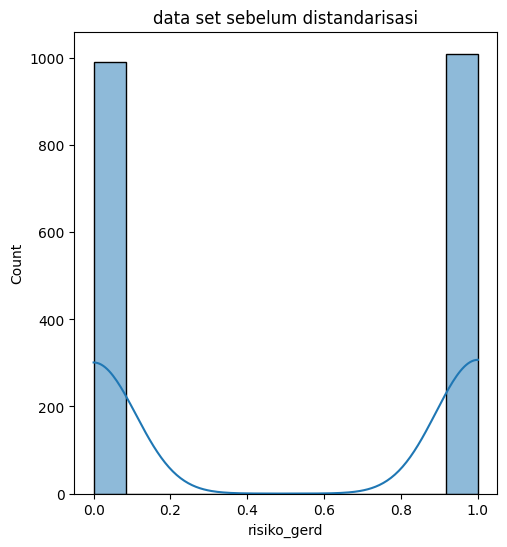

In [ ]:
#standarisasi data 

#melihat data sebelum distandarisasi

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(model['risiko_gerd'], kde=True)
plt.title("data set sebelum distandarisasi")
plt.show()

#strandarisasi data

scaler = StandardScaler()